# Sieć neuronowa

#### Import bibliotek

In [26]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

### Własna implementacja warstwy

In [27]:
def relu(x): return np.maximum(0, x)
def d_relu(x): return (x > 0).astype(float)

def softmax(x):
    exps = np.exp(x - np.max(x, axis=1, keepdims=True))
    return exps / np.sum(exps, axis=1, keepdims=True)

class Layer:
    def __init__(self, n_inputs, n_outputs, activation='relu'):
        self.w = np.random.randn(n_inputs, n_outputs) * np.sqrt(2. / n_inputs)
        self.b = np.zeros((1, n_outputs))
        self.activation = activation

    def activate(self, x):
        self.z = x @ self.w + self.b
        if self.activation == 'relu':
            self.a = relu(self.z)
        elif self.activation == 'softmax':
            self.a = softmax(self.z)
        else:
            raise ValueError("Unsupported activation")
        return self.a

    def activation_derivative(self):
        if self.activation == 'relu':
            return d_relu(self.z)
        else:
            raise NotImplementedError("Only relu backprop implemented for hidden layers.")


### Własna implementcja sieci

In [28]:
class NeuralNet:
    def __init__(self, layers_dims, lr=0.01, epochs=1000):
        self.lr = lr
        self.epochs = epochs
        self.layers = []

        # Tworzenie warstw
        for i in range(len(layers_dims)-2):
            self.layers.append(Layer(layers_dims[i], layers_dims[i+1], activation='relu'))
        self.layers.append(Layer(layers_dims[-2], layers_dims[-1], activation='softmax'))

    def forward(self, X):
        a = X
        for layer in self.layers:
            a = layer.activate(a)
        return a

    def backward(self, X, y_true):
        m = y_true.shape[0]
        y_pred = self.layers[-1].a
        delta = y_pred - y_true 

        for i in reversed(range(len(self.layers))):
            a_prev = X if i == 0 else self.layers[i-1].a
            dw = (a_prev.T @ delta) / m
            db = np.sum(delta, axis=0, keepdims=True) / m

            self.layers[i].w -= self.lr * dw
            self.layers[i].b -= self.lr * db

            if i != 0:
                delta = (delta @ self.layers[i].w.T) * self.layers[i-1].activation_derivative()

    def train(self, X, y):
        for epoch in range(self.epochs):
            y_pred = self.forward(X)
            self.backward(X, y)
            if epoch % 100 == 0:
                loss = -np.sum(y * np.log(y_pred + 1e-8)) / y.shape[0]
                print(f"Epoch {epoch}, loss = {loss:.4f}")

    def predict(self, X):
        return np.argmax(self.forward(X), axis=1)

#### Genrowanie danych

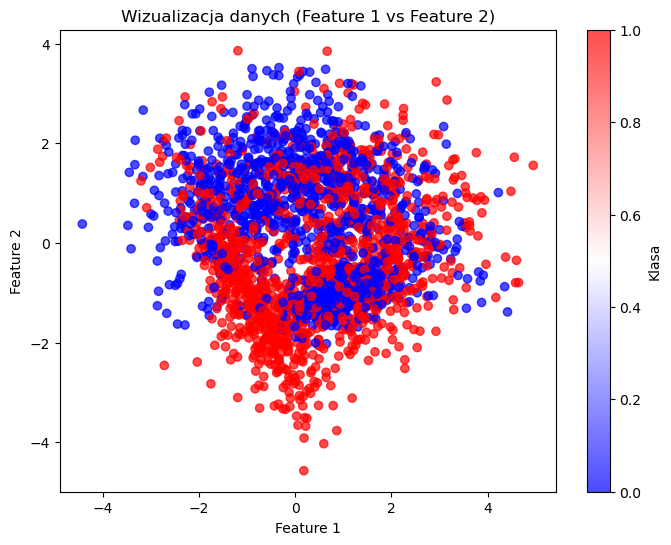

In [29]:
my_index = 259199
my_n_samples = int(str(my_index)[0]+ str(my_index)[1] + str(my_index)[-2] + str(my_index)[-1])

X, y = make_classification(
    n_samples=my_n_samples, 
    n_features=3, 
    n_informative=3,
    n_redundant=0, 
    n_classes=2, 
    n_clusters_per_class=3,
    random_state=my_index
)
y = y.reshape(-1, 1)
enc = OneHotEncoder(sparse=False)
y_onehot = enc.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y_onehot, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y.ravel(), cmap='bwr', alpha=0.7)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Wizualizacja danych (Feature 1 vs Feature 2)')
plt.colorbar(label='Klasa')
plt.show()


In [31]:
net = NeuralNet(layers_dims=[3, 10, 10, 2], lr=0.05, epochs=1000)
net.train(X_train, y_train)

y_pred = net.predict(X_test)
y_true = np.argmax(y_test, axis=1)
acc = accuracy_score(y_true, y_pred)
print(f"Dokładność: {acc:.4f}")


Epoch 0, loss = 0.6085
Epoch 100, loss = 0.4254
Epoch 200, loss = 0.3807
Epoch 300, loss = 0.3541
Epoch 400, loss = 0.3330
Epoch 500, loss = 0.3182
Epoch 600, loss = 0.3071
Epoch 700, loss = 0.2989
Epoch 800, loss = 0.2924
Epoch 900, loss = 0.2871
Dokładność: 0.8750
